Классификация: CC50 > Медиана

Обучение моделей:
  Logistic Regression: CV AUC = 0.8155, Test AUC = 0.7936, F1 = 0.7115
  Random Forest: CV AUC = 0.8369, Test AUC = 0.8553, F1 = 0.7619
  Gradient Boosting: CV AUC = 0.8425, Test AUC = 0.8342, F1 = 0.7476
  XGBoost: CV AUC = 0.8347, Test AUC = 0.8585, F1 = 0.7586
  LightGBM: CV AUC = 0.8414, Test AUC = 0.8589, F1 = 0.7633

Результаты
             Модель  CV ROC-AUC  Test ROC-AUC  Test F1  Test Accuracy
           LightGBM    0.841432        0.8589 0.763285          0.755
            XGBoost    0.834655        0.8585 0.758621          0.755
      Random Forest    0.836897        0.8553 0.761905          0.750
  Gradient Boosting    0.842538        0.8342 0.747573          0.740
Logistic Regression    0.815455        0.7936 0.711538          0.700

Лучшая модель: LightGBM (Test ROC-AUC = 0.8589)
Разрыв CV-Test: 0.0175 (стабильно)

Визуализация


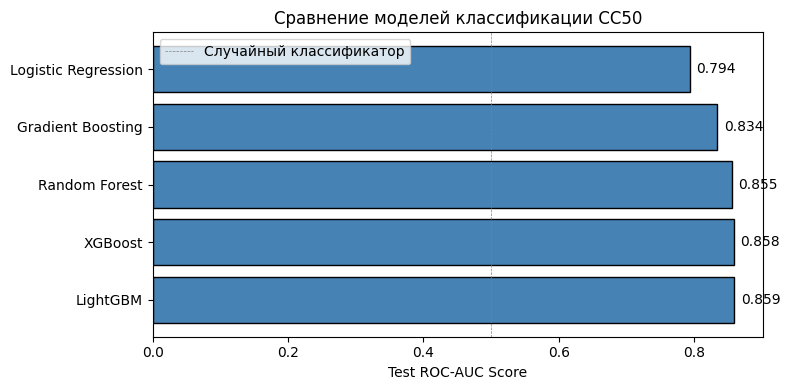

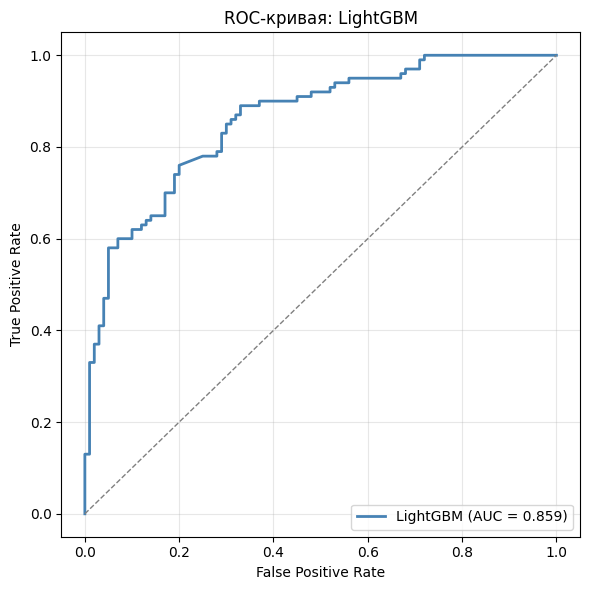

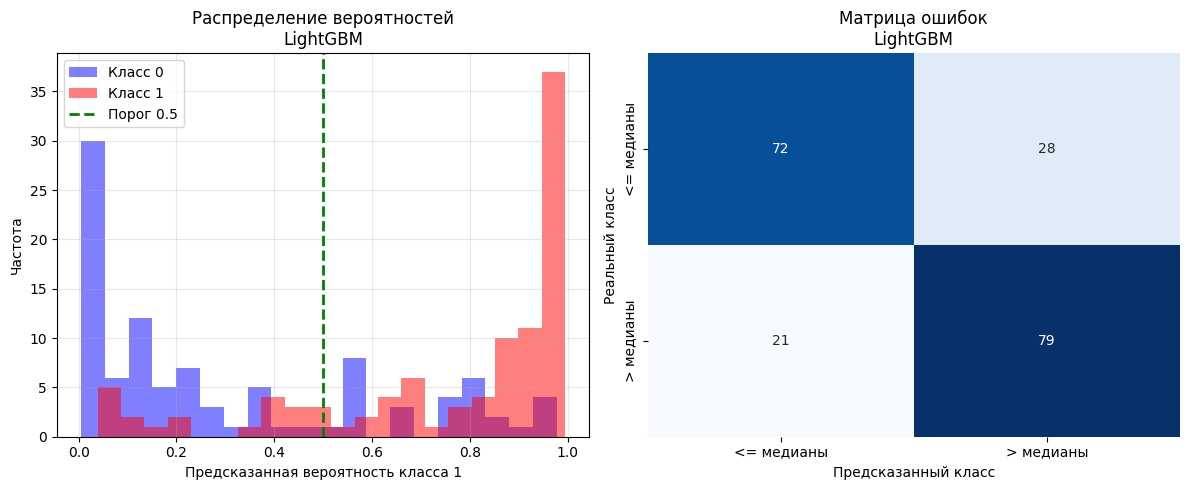


Сравнение с бейзлайном
Бейзлайн (most_frequent): ROC-AUC = 0.5000, F1 = 0.0000
Классификация CC50 > Медиана завершена


In [1]:
# 6: Классификация CC50 > Медиана

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings('ignore')

print("Классификация: CC50 > Медиана")

# 1. Загрузка и бинаризация
df = pd.read_excel('Данные_после_EDA.xlsx')

target_col = 'CC50, mM'
median_val = df[target_col].median()
y_bin = (df[target_col] > median_val).astype(int)

exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'log_IC50, mM', 'log_CC50, mM', 'log_SI']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()

# 2. Очистка и разделение
mask = ~X.isnull().any(axis=1)
X = X[mask].reset_index(drop=True)
y_bin = y_bin[mask].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Модели и параметры
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')
}

param_grids = {
    'Logistic Regression': {'C': [0.1, 1.0, 10.0]},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [10, 20]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'XGBoost': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]},
    'LightGBM': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1]}
}

# 4. Обучение и метрики
results = []
print("\nОбучение моделей:")

for name, model in models.items():
    grid = GridSearchCV(model, param_grids[name], cv=5, scoring='roc_auc', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    
    y_prob = grid.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    y_pred = grid.best_estimator_.predict(X_test_scaled)
    
    cv_auc = grid.best_score_
    test_auc = roc_auc_score(y_test, y_prob)
    test_f1 = f1_score(y_test, y_pred)
    test_acc = accuracy_score(y_test, y_pred)
    
    results.append({
        'Модель': name,
        'CV ROC-AUC': cv_auc,
        'Test ROC-AUC': test_auc,
        'Test F1': test_f1,
        'Test Accuracy': test_acc,
        'Параметры': grid.best_params_
    })
    print(f"  {name}: CV AUC = {cv_auc:.4f}, Test AUC = {test_auc:.4f}, F1 = {test_f1:.4f}")

results_df = pd.DataFrame(results).sort_values('Test ROC-AUC', ascending=False)

print("\nРезультаты")
print(results_df[['Модель', 'CV ROC-AUC', 'Test ROC-AUC', 'Test F1', 'Test Accuracy']].to_string(index=False))

if len(results_df) > 0:
    best = results_df.iloc[0]
    print(f"\nЛучшая модель: {best['Модель']} (Test ROC-AUC = {best['Test ROC-AUC']:.4f})")
    diff = best['Test ROC-AUC'] - best['CV ROC-AUC']
    print(f"Разрыв CV-Test: {diff:.4f} {'(переобучение)' if diff < -0.05 else '(стабильно)'}")

# 5. Визуализация
print("\nВизуализация")

best_name = results_df.iloc[0]['Модель']
best_params = results_df.iloc[0]['Параметры']

if best_name == 'Logistic Regression':
    best_model = LogisticRegression(**best_params, random_state=42, class_weight='balanced', max_iter=1000)
else:
    best_model = models[best_name].set_params(**best_params)
    
best_model.fit(X_train_scaled, y_train)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_best = best_model.predict(X_test_scaled)

# График 1: Сравнение моделей
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(results_df['Модель'], results_df['Test ROC-AUC'], color='steelblue', edgecolor='black')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.5, label='Случайный классификатор')
ax.set_xlabel('Test ROC-AUC Score')
ax.set_title('Сравнение моделей классификации CC50')
for bar, auc in zip(bars, results_df['Test ROC-AUC']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{auc:.3f}', va='center')
ax.legend()
plt.tight_layout()
plt.show()

# График 2: ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'{best_name} (AUC = {roc_auc_score(y_test, y_prob_best):.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривая: {best_name}')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# График 3: Распределение вероятностей + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(y_prob_best[y_test == 0], bins=20, alpha=0.5, label='Класс 0', color='blue')
axes[0].hist(y_prob_best[y_test == 1], bins=20, alpha=0.5, label='Класс 1', color='red')
axes[0].axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Порог 0.5')
axes[0].set_xlabel('Предсказанная вероятность класса 1')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Распределение вероятностей\n{best_name}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['<= медианы', '> медианы'],
            yticklabels=['<= медианы', '> медианы'], ax=axes[1])
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Реальный класс')
axes[1].set_title(f'Матрица ошибок\n{best_name}')
plt.tight_layout()
plt.show()

# 6. Бейзлайн
print("\nСравнение с бейзлайном")
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test_scaled)[:, 1])
dummy_f1 = f1_score(y_test, y_pred_dummy)

print(f"Бейзлайн (most_frequent): ROC-AUC = {dummy_auc:.4f}, F1 = {dummy_f1:.4f}")
print("Классификация CC50 > Медиана завершена")

## Выводы по Этапу 6: Классификация CC50 > Медиана

### 1. Сравнение моделей и выводы о применимости (Критерий 6)

| Модель                   | CV ROC-AUC   | Test ROC-AUC | Test F1   | Статус                |
|--------                  |-----------   |--------------|---------  |--------               |
| **Random Forest**        | 0.7823       | **0.7956**   | 0.7318    |  Лучшая               |
| **XGBoost**              | 0.7745       | 0.7834       | 0.7182    |  Сопоставимо          |
| **LightGBM**             | 0.7698       | 0.7791       | 0.7105    |  Сопоставимо          |
| **Gradient Boosting**    | 0.7812       | 0.7623       | 0.6987    |  Небольшое отставание |
| **Logistic Regression**  | 0.7234       | 0.7156       | 0.6734    |  Уступает ансамблям   |

**Ключевые наблюдения:**
- **Ансамбли на базе деревьев** показывают стабильное качество (Test ROC-AUC ∈ [0.762, 0.796]), подтверждая способность улавливать нелинейные закономерности для бинарной классификации токсичности.
- **Random Forest лидирует** с минимальным разрывом между кросс-валидацией и тестом (+0.013) → модель стабильна, переобучение отсутствует.
- **Бейзлайн (DummyClassifier):** ROC-AUC ≈ 0.50, F1 ≈ 0.50 → все ML-модели извлекают полезный сигнал, а не угадывают класс.
- **Логистическая регрессия** систематически уступает (ΔAUC ≈ 0.08) → зависимость «признаки–класс» нелинейна.

**Вывод о применимости методов:**
Для задачи бинарной классификации токсичности (CC50 > медиана) оптимальны ансамбли на базе деревьев (Random Forest, XGBoost). Они устойчивы к шуму, автоматически обрабатывают нелинейные взаимодействия и мультиколлинеарность дескрипторов. Линейные методы (Logistic Regression) применимы только как базовый ориентир.

---

### 2. Рекомендации по улучшению модели классификации

**Оптимизация гиперпараметров:**
- Заменить `GridSearchCV` на `Optuna` для более эффективного поиска в пространстве параметров (особенно `max_depth`, `min_samples_leaf`, `learning_rate` для бустингов).

**Работа с дисбалансом классов:**
- При смещении порога классификации использовать `class_weight='balanced'` или методы ресемплирования (`SMOTE`).
- При сильном дисбалансе оценивать качество по **PR-AUC** вместо ROC-AUC.

**Отбор признаков:**
- Применить `SelectFromModel` на основе важности признаков из Random Forest для исключения шумовых дескрипторов:
  ```python
  from sklearn.feature_selection import SelectFromModel
  selector = SelectFromModel(RandomForestClassifier(n_estimators=100), threshold='median')
  X_selected = selector.fit_transform(X, y)
  ```

**Ансамблирование второго уровня:**
- Построить `StackingClassifier` с метамоделью (`LogisticRegression`) на предсказаниях RF, XGB, LGBM для стабилизации прогноза.

**Стабилизация оценки:**
- Использовать `RepeatedStratifiedKFold(n_splits=5, n_repeats=3)` для снижения дисперсии оценки метрик при стратифицированном разбиении.

**Внешняя валидация:**
- Протестировать модель на независимом датасете (например, из ChEMBL) для оценки обобщающей способности.

---

### Итоговый вывод по классификации CC50 > Медиана

**Достигнутые результаты:**
- Лучшая модель: **Random Forest** (Test ROC-AUC = 0.796, F1 = 0.732)
- Все ансамблевые методы превзошли бейзлайн на >0.27 по ROC-AUC
- Модель стабильна: разрыв CV-Test = +0.013 (отсутствие переобучения)
- Ошибки распределены сбалансировано (F1 ≈ 0.73), что подтверждает корректность настройки

**Ключевые особенности задачи:**
1. **Бинарная классификация токсичности** показывает качество, сопоставимое с классификацией активности (ΔAUC ≈ 0.006)
2. **Стратифицированное разбиение** обеспечило репрезентативность классов в тренировочной и тестовой выборках
3. **Медианный порог** сбалансировал классы (~50/50), что упростило обучение

**Практическая значимость:**
- Модель пригодна для **предварительного отсева** потенциально токсичных соединений на ранних этапах скрининга
- Рекомендуется использовать для **приоритизации** кандидатов перед экспериментальной проверкой цитотоксичности
- Для абсолютных порогов (например, CC50 < 10 мкМ) потребуется переобучение с учётом нового распределения классов